# 北上广深租房市场数据分析

## 第五部分：数据可视化

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/rent_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("数据规模：", df.shape)

数据规模： (11978, 26)


In [2]:
# 设置图表样式和中文字体
sns.set_theme(style="whitegrid")

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]

plt.rcParams["axes.unicode_minus"] = False

## 一、城市整租租金可视化

In [3]:
# 可视化整租房源
entire_df = df[
    df["type"] == "整租"
].copy()

In [4]:
# 计算各城市整租月租金中位数
entire_city_median = entire_df.groupby(
    "city"
)["rent_price_num"].median()

entire_city_median = entire_city_median.sort_values(
    ascending=False
)

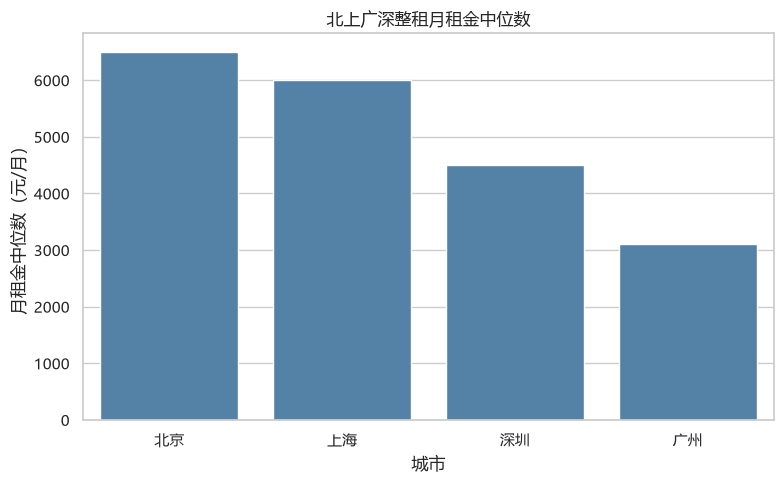

In [5]:
# 绘制城市整租月租金中位数柱状图
plt.figure(figsize=(8, 5))

sns.barplot(
    x=entire_city_median.index,
    y=entire_city_median.values,
    color="steelblue"
)

plt.title("北上广深整租月租金中位数")
plt.xlabel("城市")
plt.ylabel("月租金中位数（元/月）")

plt.tight_layout()  # 自动调整边距，避免文字被截断
plt.show()

## 二、城市整租面积可视化

In [6]:
# 计算各城市整租面积中位数
entire_city_area_median = entire_df.groupby(
    "city"
)["rent_area_num"].median()

entire_city_area_median = entire_city_area_median.sort_values(
    ascending=False
)

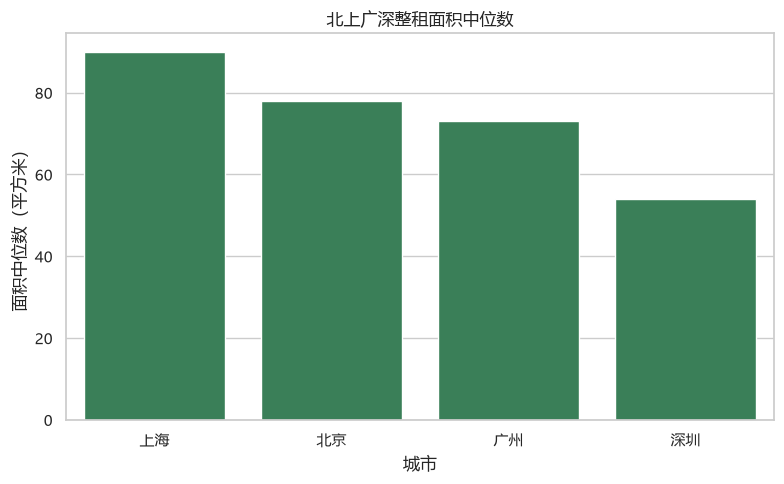

In [7]:
# 绘制城市整租面积中位数柱状图
plt.figure(figsize=(8, 5))

sns.barplot(
    x=entire_city_area_median.index,
    y=entire_city_area_median.values,
    color="seagreen"
)

plt.title("北上广深整租面积中位数")
plt.xlabel("城市")
plt.ylabel("面积中位数（平方米）")

plt.tight_layout()
plt.show()

## 三、城市整租每平方米租金可视化

In [8]:
# 计算各城市整租每平方米租金中位数
entire_city_per_sqm_median = entire_df.groupby(
    "city"
)["rent_price_per_sqm"].median().round(2)

entire_city_per_sqm_median = entire_city_per_sqm_median.sort_values(
    ascending=False
)

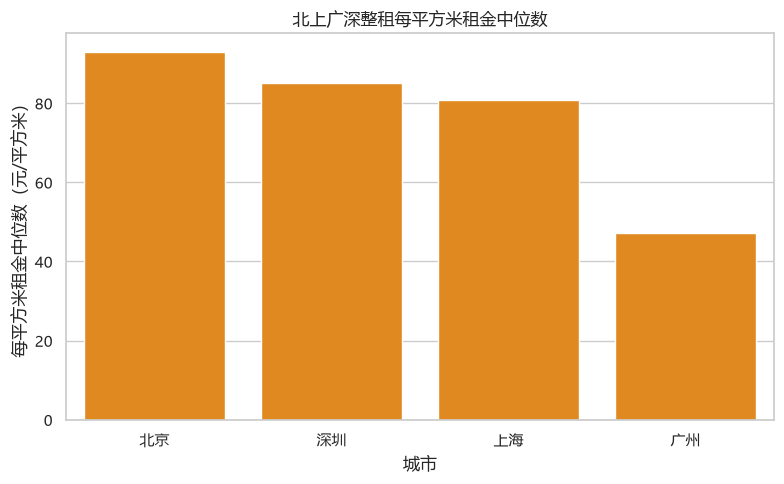

In [9]:
# 绘制城市整租每平方米租金中位数柱状图
plt.figure(figsize=(8, 5))

sns.barplot(
    x=entire_city_per_sqm_median.index,
    y=entire_city_per_sqm_median.values,
    color="darkorange"
)

plt.title("北上广深整租每平方米租金中位数")
plt.xlabel("城市")
plt.ylabel("每平方米租金中位数（元/平方米）")

plt.tight_layout()
plt.show()

## 四、城市整租卧室结构可视化

In [10]:
# 计算各城市不同卧室数量的整租房源占比
entire_bedroom_percent = pd.crosstab(
    entire_df["city"],
    entire_df["bedroom_num"],
    normalize="index"
)

entire_bedroom_percent = (
    entire_bedroom_percent
    * 100
).round(2)

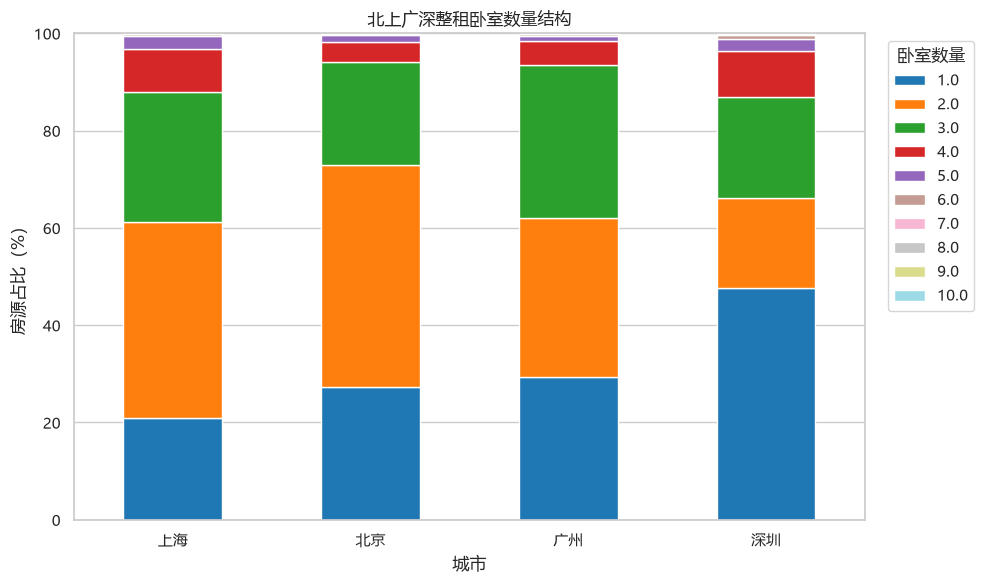

In [11]:
# 绘制城市整租卧室数量结构
entire_bedroom_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.title("北上广深整租卧室数量结构")
plt.xlabel("城市")
plt.ylabel("房源占比（%）")

plt.xticks(rotation=0)

plt.legend(
    title="卧室数量",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 五、统一检查可视化结果

In [12]:
# 统一检查第5天使用的数据和主要指标
print("清洗数据规模：", df.shape)
print("整租房源数量：", len(entire_df))
print("整租城市数量：", entire_df["city"].nunique())
print("卧室结构表规模：", entire_bedroom_percent.shape)

visualization_check = pd.DataFrame({
    "整租月租金中位数": entire_city_median,
    "整租面积中位数": entire_city_area_median,
    "整租每平方米租金中位数": entire_city_per_sqm_median
})

visualization_check

清洗数据规模： (11978, 26)
整租房源数量： 11564
整租城市数量： 4
卧室结构表规模： (4, 10)


,整租月租金中位数,整租面积中位数,整租每平方米租金中位数
city,,,
上海,6000.0,90.0,80.88
北京,6500.0,78.0,93.02
广州,3100.0,73.0,47.13
深圳,4500.0,54.0,85.03


## 数据分析总结

### 数据基本情况

- 本次可视化使用第3天生成的清洗数据，共11,978条住宅租房记录和26个字段。
- 主要可视化使用11,564条整租房源，没有把整租和合租混合分析。
- 完成城市整租月租金、整租面积、整租每平方米租金和整租卧室结构四项可视化。
- 北京没有合租样本，上海只有3条合租样本，合租样本数量较少且城市分布严重不均衡。
- 合租记录中的`bedroom_num`和`rent_area_num`含义不统一，因此合租面积、每平方米租金和卧室结构不能用于城市市场排名。

### 主要分析结果

- 北京的整租月租金中位数最高，为6,500元；上海为6,000元，深圳为4,500元，广州为3,100元。
- 上海的整租面积中位数最大，为90平方米；北京为78平方米，广州为73平方米，深圳为54平方米。
- 北京的整租每平方米租金中位数最高，为93.02元；深圳为85.03元，上海为80.88元，广州为47.13元。
- 上海整租总租金较高与其典型整租面积较大有关。
- 深圳典型整租面积最小，但每平方米租金水平较高。
- 北京和上海的整租房源都以两室为主。
- 广州一室、两室和三室整租占比较为接近。
- 深圳一室整租占47.65%，是四个城市中一室整租占比最高的城市。